In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

# Load data
daily_sales = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])
daily_sales.set_index('ds', inplace=True)


In [2]:
def adf_test(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    
    if result[1] <= 0.05:
        print("✓ Series is stationary (reject H0)")
    else:
        print("✗ Series is non-stationary (fail to reject H0)")

print("=" * 50)
print("ADF Test on Original Series")
print("=" * 50)
adf_test(daily_sales['y'].dropna())

ADF Test on Original Series
ADF Statistic: -2.8448262658750845
p-value: 0.052150437760087605
Critical Values:
	1%: -3.439490435810785
	5%: -2.8655738086413374
	10%: -2.568918067209286
✗ Series is non-stationary (fail to reject H0)


In [3]:
def kpss_test(timeseries):
    result = kpss(timeseries, regression='c', nlags='auto')
    print('\nKPSS Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'\t{key}: {value}')
    
    if result[1] > 0.05:
        print("✓ Series is stationary (fail to reject H0)")
    else:
        print("✗ Series is non-stationary (reject H0)")

print("\n" + "=" * 50)
print("KPSS Test on Original Series")
print("=" * 50)
kpss_test(daily_sales['y'].dropna())


KPSS Test on Original Series

KPSS Statistic: 0.5392712082108476
p-value: 0.03282179995251179
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
✗ Series is non-stationary (reject H0)


In [4]:
daily_sales['y_diff'] = daily_sales['y'].diff()

print("\n" + "=" * 50)
print("ADF Test on Differenced Series")
print("=" * 50)
adf_test(daily_sales['y_diff'].dropna())


ADF Test on Differenced Series
ADF Statistic: -7.790869577583392
p-value: 7.948658188823161e-12
Critical Values:
	1%: -3.439503230053971
	5%: -2.8655794463678346
	10%: -2.5689210707289982
✓ Series is stationary (reject H0)


In [7]:
if daily_sales_filled.isnull().any():
    print("⚠️ Warning: Still have missing values. Using interpolation...")
    daily_sales_filled = daily_sales_filled.interpolate(method='linear')


⚠️ Warning: Zero or negative values found. Using additive model instead.
Decomposition successful!


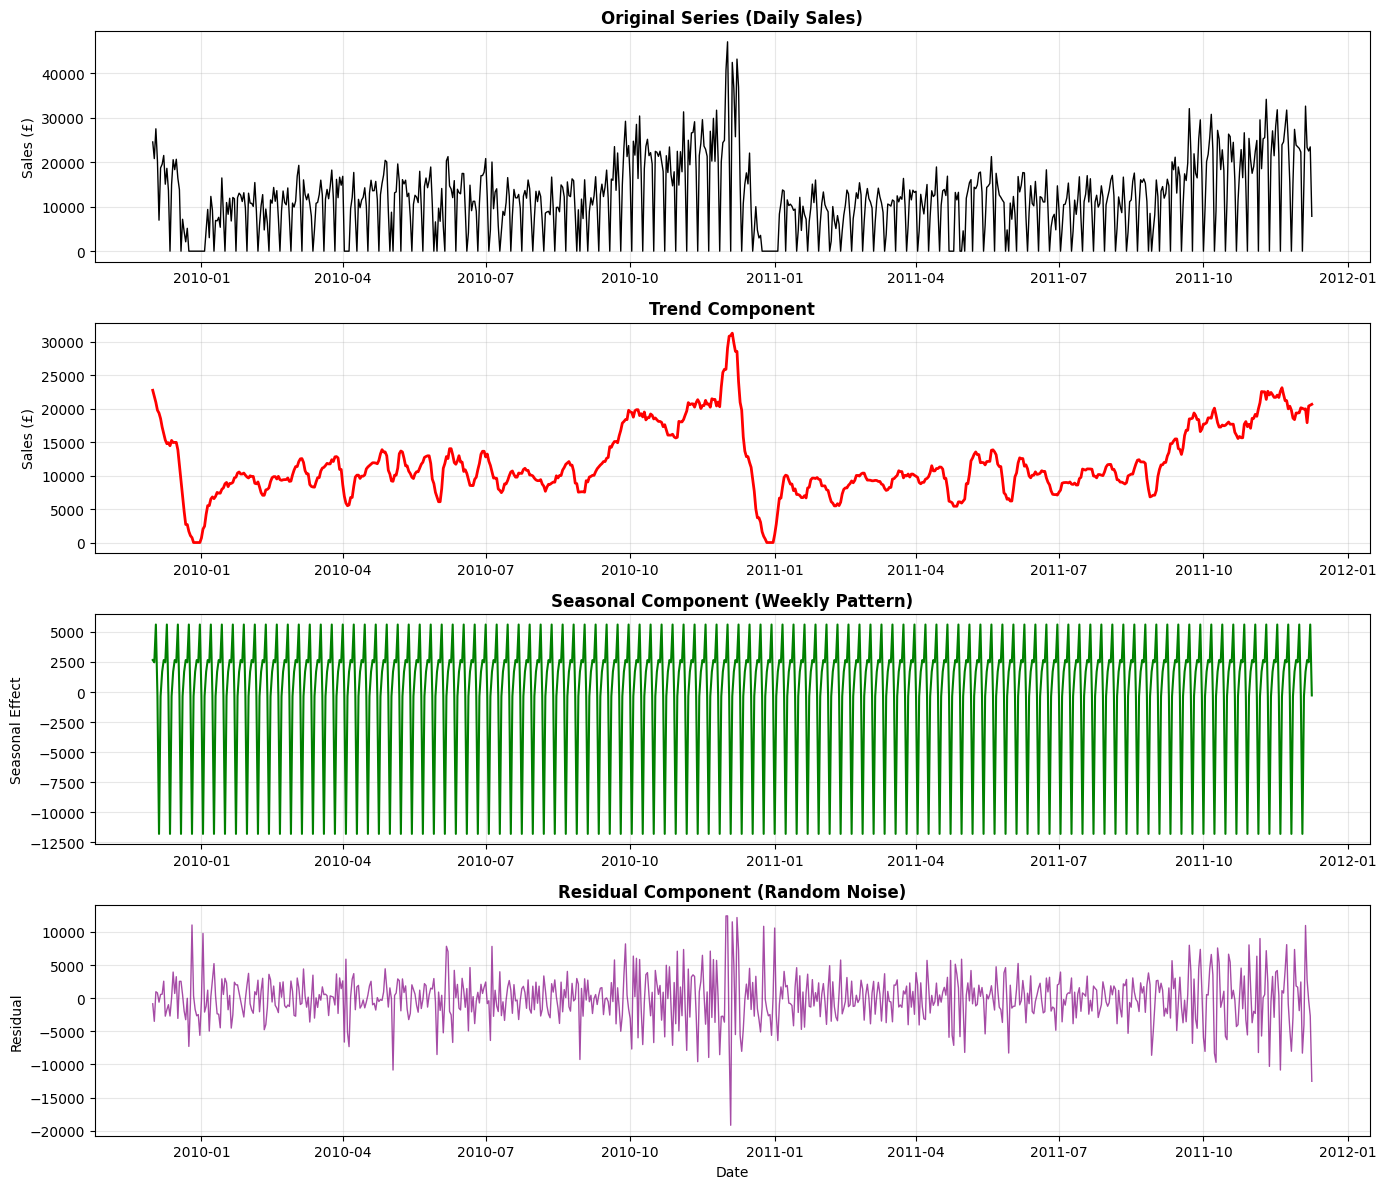


Decomposition plot saved to: ../data/processed/time_series_decomposition.png


In [13]:
if (daily_sales_filled <= 0).any():
    print("⚠️ Warning: Zero or negative values found. Using additive model instead.")
    model_type = 'additive'
    # Add small constant to avoid zeros
    daily_sales_filled = daily_sales_filled + 0.01
else:
    model_type = 'multiplicative'
    print(f"Using {model_type} model for decomposition")

# Perform decomposition
try:
    decomposition = seasonal_decompose(
        daily_sales_filled, 
        model=model_type, 
        period=7,  # Weekly seasonality
        extrapolate_trend='freq'  # Handle edge effects
    )
    print("Decomposition successful!")
except Exception as e:
    print(f"Error with decomposition: {e}")
    print("Trying with additive model and shorter period...")
    decomposition = seasonal_decompose(
        daily_sales_filled, 
        model='additive', 
        period=7
    )

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original series
axes[0].plot(decomposition.observed.index, decomposition.observed.values, 
             color='black', linewidth=1)
axes[0].set_title('Original Series (Daily Sales)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales (£)')
axes[0].grid(True, alpha=0.3)

# Trend component
axes[1].plot(decomposition.trend.index, decomposition.trend.values, 
             color='red', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sales (£)')
axes[1].grid(True, alpha=0.3)

# Seasonal component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, 
             color='green', linewidth=1.5)
axes[2].set_title('Seasonal Component (Weekly Pattern)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal Effect')
axes[2].grid(True, alpha=0.3)

# Residual component
axes[3].plot(decomposition.resid.index, decomposition.resid.values, 
             color='purple', linewidth=1, alpha=0.7)
axes[3].set_title('Residual Component (Random Noise)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/time_series_decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nDecomposition plot saved to: ../data/processed/time_series_decomposition.png")